Epoch 0, Loss: 236.1227
Epoch 100, Loss: 90.4288
Epoch 200, Loss: 94.0735
Epoch 300, Loss: 93.8727
Epoch 400, Loss: 108.1692
Epoch 500, Loss: 92.8423
Epoch 600, Loss: 112.6182
Epoch 700, Loss: 92.0869
Epoch 800, Loss: 96.4838
Epoch 900, Loss: 113.4666
Final Accuracy: 78.5 %


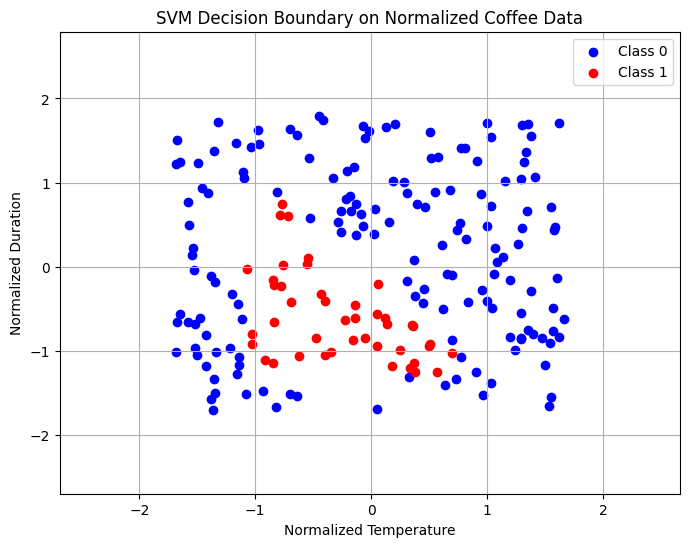

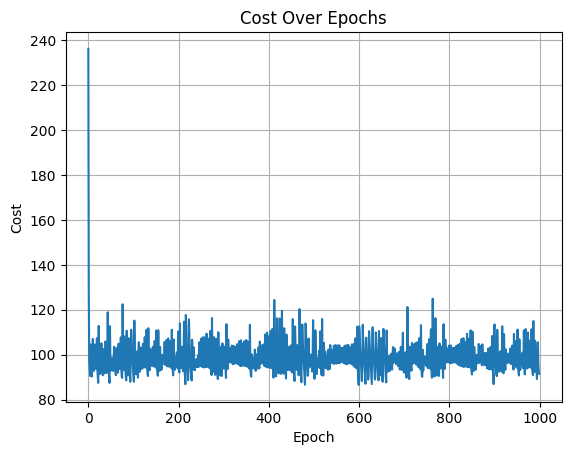

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
def load_coffee_data():
    rng = np.random.default_rng(2)
    X = rng.random(400).reshape(-1, 2)
    X[:, 1] = X[:, 1] * 4 + 11.5
    X[:, 0] = X[:, 0] * (285 - 150) + 150
    Y = np.zeros(len(X))
    for i, (t, d) in enumerate(X):
        y = -3/(260-175)*t + 21
        Y[i] = 1 if (175 < t < 260 and 12 < d < 15 and d <= y) else 0
    return X, Y.reshape(-1, 1)

# Load and normalize
X, y = load_coffee_data()
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_norm = (X - X_mean) / X_std
y = y * 2 - 1  # Convert labels to {-1, 1}

# Initialize
W = np.random.randn(2, 1)
b = 0.0
C = 1.0
lr = 0.01
epochs = 1000
costs = []

# Train using gradient descent
for epoch in range(epochs):
    margin = y * (X_norm @ W + b)
    loss = 0.5 * np.sum(W**2) + C * np.sum(np.maximum(0, 1 - margin))
    indicator = (margin < 1).astype(float)
    dW = W - C * (X_norm.T @ (indicator * y))
    db = -C * np.sum(indicator * y)
    W -= lr * dW
    b -= lr * db
    costs.append(loss)
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

# Prediction
y_pred = np.sign(X_norm @ W + b)
acc = np.mean(y_pred.flatten() == y.flatten())
print("Final Accuracy:", acc * 100, "%")

# 🔲 Decision Boundary Plot
xx, yy = np.meshgrid(
    np.linspace(X_norm[:, 0].min() - 1, X_norm[:, 0].max() + 1, 500),
    np.linspace(X_norm[:, 1].min() - 1, X_norm[:, 1].max() + 1, 500)
)
grid = np.c_[xx.ravel(), yy.ravel()]
Z = np.sign(grid @ W + b).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contour(xx, yy, Z, levels=[0], colors='k', linewidths=2)
plt.scatter(X_norm[y[:, 0] == -1][:, 0], X_norm[y[:, 0] == -1][:, 1], color='blue', label='Class 0')
plt.scatter(X_norm[y[:, 0] == 1][:, 0], X_norm[y[:, 0] == 1][:, 1], color='red', label='Class 1')
plt.title("SVM Decision Boundary on Normalized Coffee Data")
plt.xlabel("Normalized Temperature")
plt.ylabel("Normalized Duration")
plt.legend()
plt.grid(True)
plt.show()

# 🔳 Cost plot
plt.plot(costs)
plt.title("Cost Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.grid(True)
plt.show()